In [22]:
import numpy as np
import matplotlib.pyplot as plt

N = 100000          # samples per realization
ENSEMBLES = 200     # number of realizations
t = np.linspace(0, 10, N)

## Question 1
Verify that the mean of power is centered around the variance of the voltage

In [23]:
# Generate voltage
sigma = 1.5
v = np.random.normal(0, sigma, N)

# Power
p = v**2

# Statistics
mean_v = np.mean(v)
var_v = np.var(v)
rms_v = np.sqrt(np.mean(v**2))
mean_p = np.mean(p)

print(f"Mean of voltage      =  {mean_v}")
print(f"Variance of voltage  =  {var_v}")
print(f"RMS of voltage       =  {rms_v}")
print(f"Mean of power (v²)   =  {mean_p}")
print(f"Difference           =  {mean_p - var_v}")

Mean of voltage      =  0.0054113980703017605
Variance of voltage  =  2.241564950721417
RMS of voltage       =  1.4971954561614498
Mean of power (v²)   =  2.241594233950492
Difference           =  2.928322907491676e-05


For a zero-mean random voltage, the mean power is equal to the second moment of the voltage, which is its variance. The numerical results show that the mean of $v^2$ closely matches the variance of $v$, with negligible error due to finite sampling.

## Question 2
Consider cases of different RMS and plot their histograms

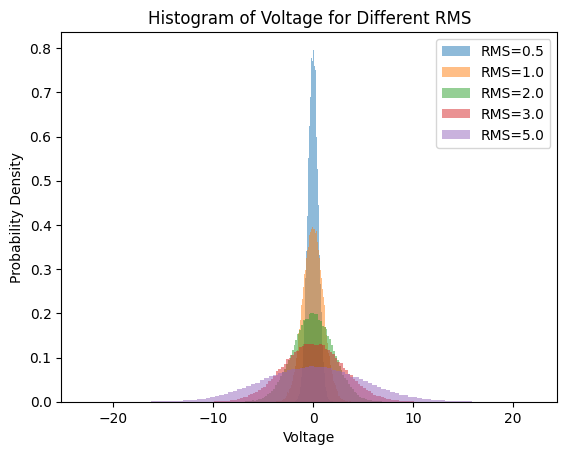

In [24]:
sigmas = [0.5, 1.0, 2.0, 3.0, 5.0]

plt.figure()
for s in sigmas:
    v = np.random.normal(0, s, N)
    plt.hist(v, bins=100, density=True, alpha=0.5, label=f"RMS={s}")

plt.title("Histogram of Voltage for Different RMS")
plt.xlabel("Voltage")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

As the RMS value of the voltage increases, the histogram becomes wider, indicating a larger spread in voltage values. The overall shape of the histogram remains Gaussian, showing that RMS affects only the scale of the distribution and not its form.

## Question 3
How will the histogram change if I add a slowly varying sine wave in it

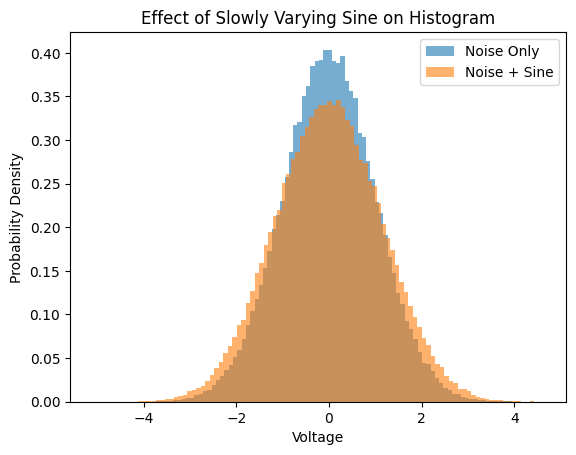

In [25]:
sigma = 1.0
noise = np.random.normal(0, sigma, N)
slow_sine = 0.8 * np.sin(2 * np.pi * 0.2 * t)
v_modified = noise + slow_sine

plt.figure()
plt.hist(noise, bins=100, density=True, alpha=0.6, label="Noise Only")
plt.hist(v_modified, bins=100, density=True, alpha=0.6, label="Noise + Sine")
plt.title("Effect of Slowly Varying Sine on Histogram")
plt.xlabel("Voltage")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

Adding a slowly varying sine wave distorts the histogram of the voltage signal. The distribution becomes broader and may develop asymmetry or multiple peaks, indicating the presence of a deterministic component superimposed on random noise.

## Question 4
How are the Variances of the ensembles distributed ?

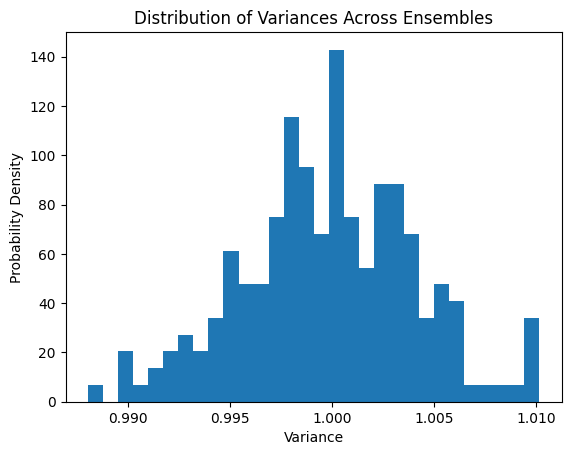

Mean of ensemble variances = 0.9998172113777456
Std of ensemble variances = 0.004221941192771717


In [26]:
variances = []

for _ in range(ENSEMBLES):
    v = np.random.normal(0, 1.0, N)
    variances.append(np.var(v))

variances = np.array(variances)

plt.figure()
plt.hist(variances, bins=30, density=True)
plt.title("Distribution of Variances Across Ensembles")
plt.xlabel("Variance")
plt.ylabel("Probability Density")
plt.show()

print("Mean of ensemble variances =", np.mean(variances))
print("Std of ensemble variances =", np.std(variances))

The variances computed from different ensemble realizations form a narrow distribution centered around the true variance. This spread arises due to finite sample effects and reduces as the number of samples increases, demonstrating statistical stability of the process.